In [1]:
from pathlib import Path
import shutil
import subprocess

import ipynbname
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib.lines import Line2D
from shapely.geometry import box

REPO_ROOT = Path(ipynbname.path()).parent.parent
DATA_ROOT = REPO_ROOT / "data"
COMMUNES_PATH = DATA_ROOT / "processed" / "shapefiles" / "communes_2021.gpkg"
POP_GRID_PATH = DATA_ROOT / "raw" / "pop" / "poland_bbox_pop_100m.parquet"


def _kpsewhich(name: str) -> str:
    if not shutil.which("kpsewhich"):
        return ""
    return subprocess.run(
        ["kpsewhich", name], capture_output=True, text=True
    ).stdout.strip()


# Matplotlib usetex always loads type1cm.sty; shim to cm-super type1ec if needed.
if not _kpsewhich("type1cm.sty"):
    shim_dir = Path.home() / "texmf" / "tex" / "latex" / "type1cm"
    shim_dir.mkdir(parents=True, exist_ok=True)
    (shim_dir / "type1cm.sty").write_text(
        "% Shim for matplotlib usetex: map type1cm -> cm-super type1ec.\n"
        "\\ProvidesPackage{type1cm}\n"
        "\\RequirePackage{type1ec}\n"
    )

# LaTeX preamble (T1 needed for Polish \k{} ogonek; siunitx optional on lean TeX Live)
_latex_preamble = r"\usepackage[T1]{fontenc}\usepackage{amsmath}\usepackage{amssymb}"
if _kpsewhich("siunitx.sty"):
    _latex_preamble += r"\usepackage{siunitx}[=v2]"

sns.set_style("whitegrid")
plt.rcParams.update({
    # 'figure.figsize': (6*2, 2*4.5),
    "font.size": 16.0,
    "font.family": "serif",
    "font.serif": "Palatino",
    "axes.titlesize": "medium",
    "figure.titlesize": "large",
    "legend.fontsize": "medium",
    # dpi for high-res output
    "figure.dpi": 100,
    "savefig.dpi": 300,
    # Tight layout by default
    "figure.autolayout": True,
    "text.usetex": True,
    "text.latex.preamble": _latex_preamble,
})

# Polish characters -> LaTeX accents (pdflatex / usetex cannot take raw Unicode here)
_PL_LATEX = {
    "ą": r"\k{a}", "ć": r"\'c", "ę": r"\k{e}", "ł": r"\l{}",
    "ń": r"\'n", "ó": r"\'o", "ś": r"\'s", "ź": r"\'z", "ż": r"\.{z}",
    "Ą": r"\k{A}", "Ć": r"\'C", "Ę": r"\k{E}", "Ł": r"\L{}",
    "Ń": r"\'N", "Ó": r"\'O", "Ś": r"\'S", "Ź": r"\'Z", "Ż": r"\.{Z}",
}


def _fix_utf8_mojibake(s: str) -> str:
    """Undo UTF-8 bytes mis-decoded as Latin-1 (common with PRG shapefiles)."""
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def latex_text(s: str) -> str:
    s = _fix_utf8_mojibake(str(s))
    for ch, rep in _PL_LATEX.items():
        s = s.replace(ch, rep)
    return s.replace("_", r"\_").replace("&", r"\&").replace("%", r"\%")


In [2]:
roads = gpd.read_file(DATA_ROOT / "raw" / "gmap" / "out" / "poland_roads_2011_full.gpkg")

In [ ]:
roads['nodes']

KeyboardInterrupt: 

In [2]:
fpi = gpd.read_file(DATA_ROOT / "processed" / "floorspace" / "gmina_floorspace_index_2021.gpkg")

In [3]:
fpi.sort_values(by="index_zl_m2", ascending=False, inplace=True)
fpi

,gmina_teryt,pop_x,nazwa,powiat,rodz_class,index_zl_m2,theta_tilde,theta_sd,shrinkage_to_data,has_rcn,n_obs,gus_median,pop_y,geometry
1420,2211023,3435,Jastarnia,2211,urban_rural,14900.398446,9.609143,0.024809,0.992150,True,413.0,7123.0,3435,"MULTIPOLYGON (((469644.614 765763.479, 469663...."
2441,0802042,4803,Dąbie,0802,rural,13982.955918,9.545594,0.017230,0.996213,True,1.0,3263.0,4803,"MULTIPOLYGON (((237196.436 454222.901, 237137...."
2358,3207043,5953,Międzyzdroje,3207,urban_rural,13424.722646,9.504853,0.013835,0.997559,True,891.0,11047.0,5953,"MULTIPOLYGON (((211492.333 689173.792, 211648...."
157,2264011,31877,Sopot,2264,urban,13352.053103,9.499425,0.005174,0.999659,True,6903.0,14233.0,31877,"MULTIPOLYGON (((473466.277 729634.34, 473454.1..."
469,1217011,24678,Zakopane,1217,urban,11817.102860,9.377303,0.009534,0.998841,True,2039.0,11027.0,24678,"MULTIPOLYGON (((571595.415 163010.122, 571613...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,1603032,5185,Cisek,1603,rural,1092.787385,6.996487,0.073440,0.931213,True,2.0,3142.0,5185,"MULTIPOLYGON (((441674.231 257401.621, 441572...."
2275,1419112,4149,Słubice,1419,rural,1051.663475,6.958128,0.003573,0.999837,True,1.0,3071.0,4149,"MULTIPOLYGON (((563607.503 496114.68, 563606.7..."
967,3007022,5639,Brzeziny,3007,rural,1017.000188,6.924613,0.002877,0.999894,True,1.0,3351.0,5639,"MULTIPOLYGON (((444834.399 407671.992, 444755...."
2329,2011062,2137,Nowy Dwór,2011,rural,1012.327458,6.920007,0.005042,0.999676,True,1.0,3491.0,2137,"MULTIPOLYGON (((797636.443 656956.262, 797635...."


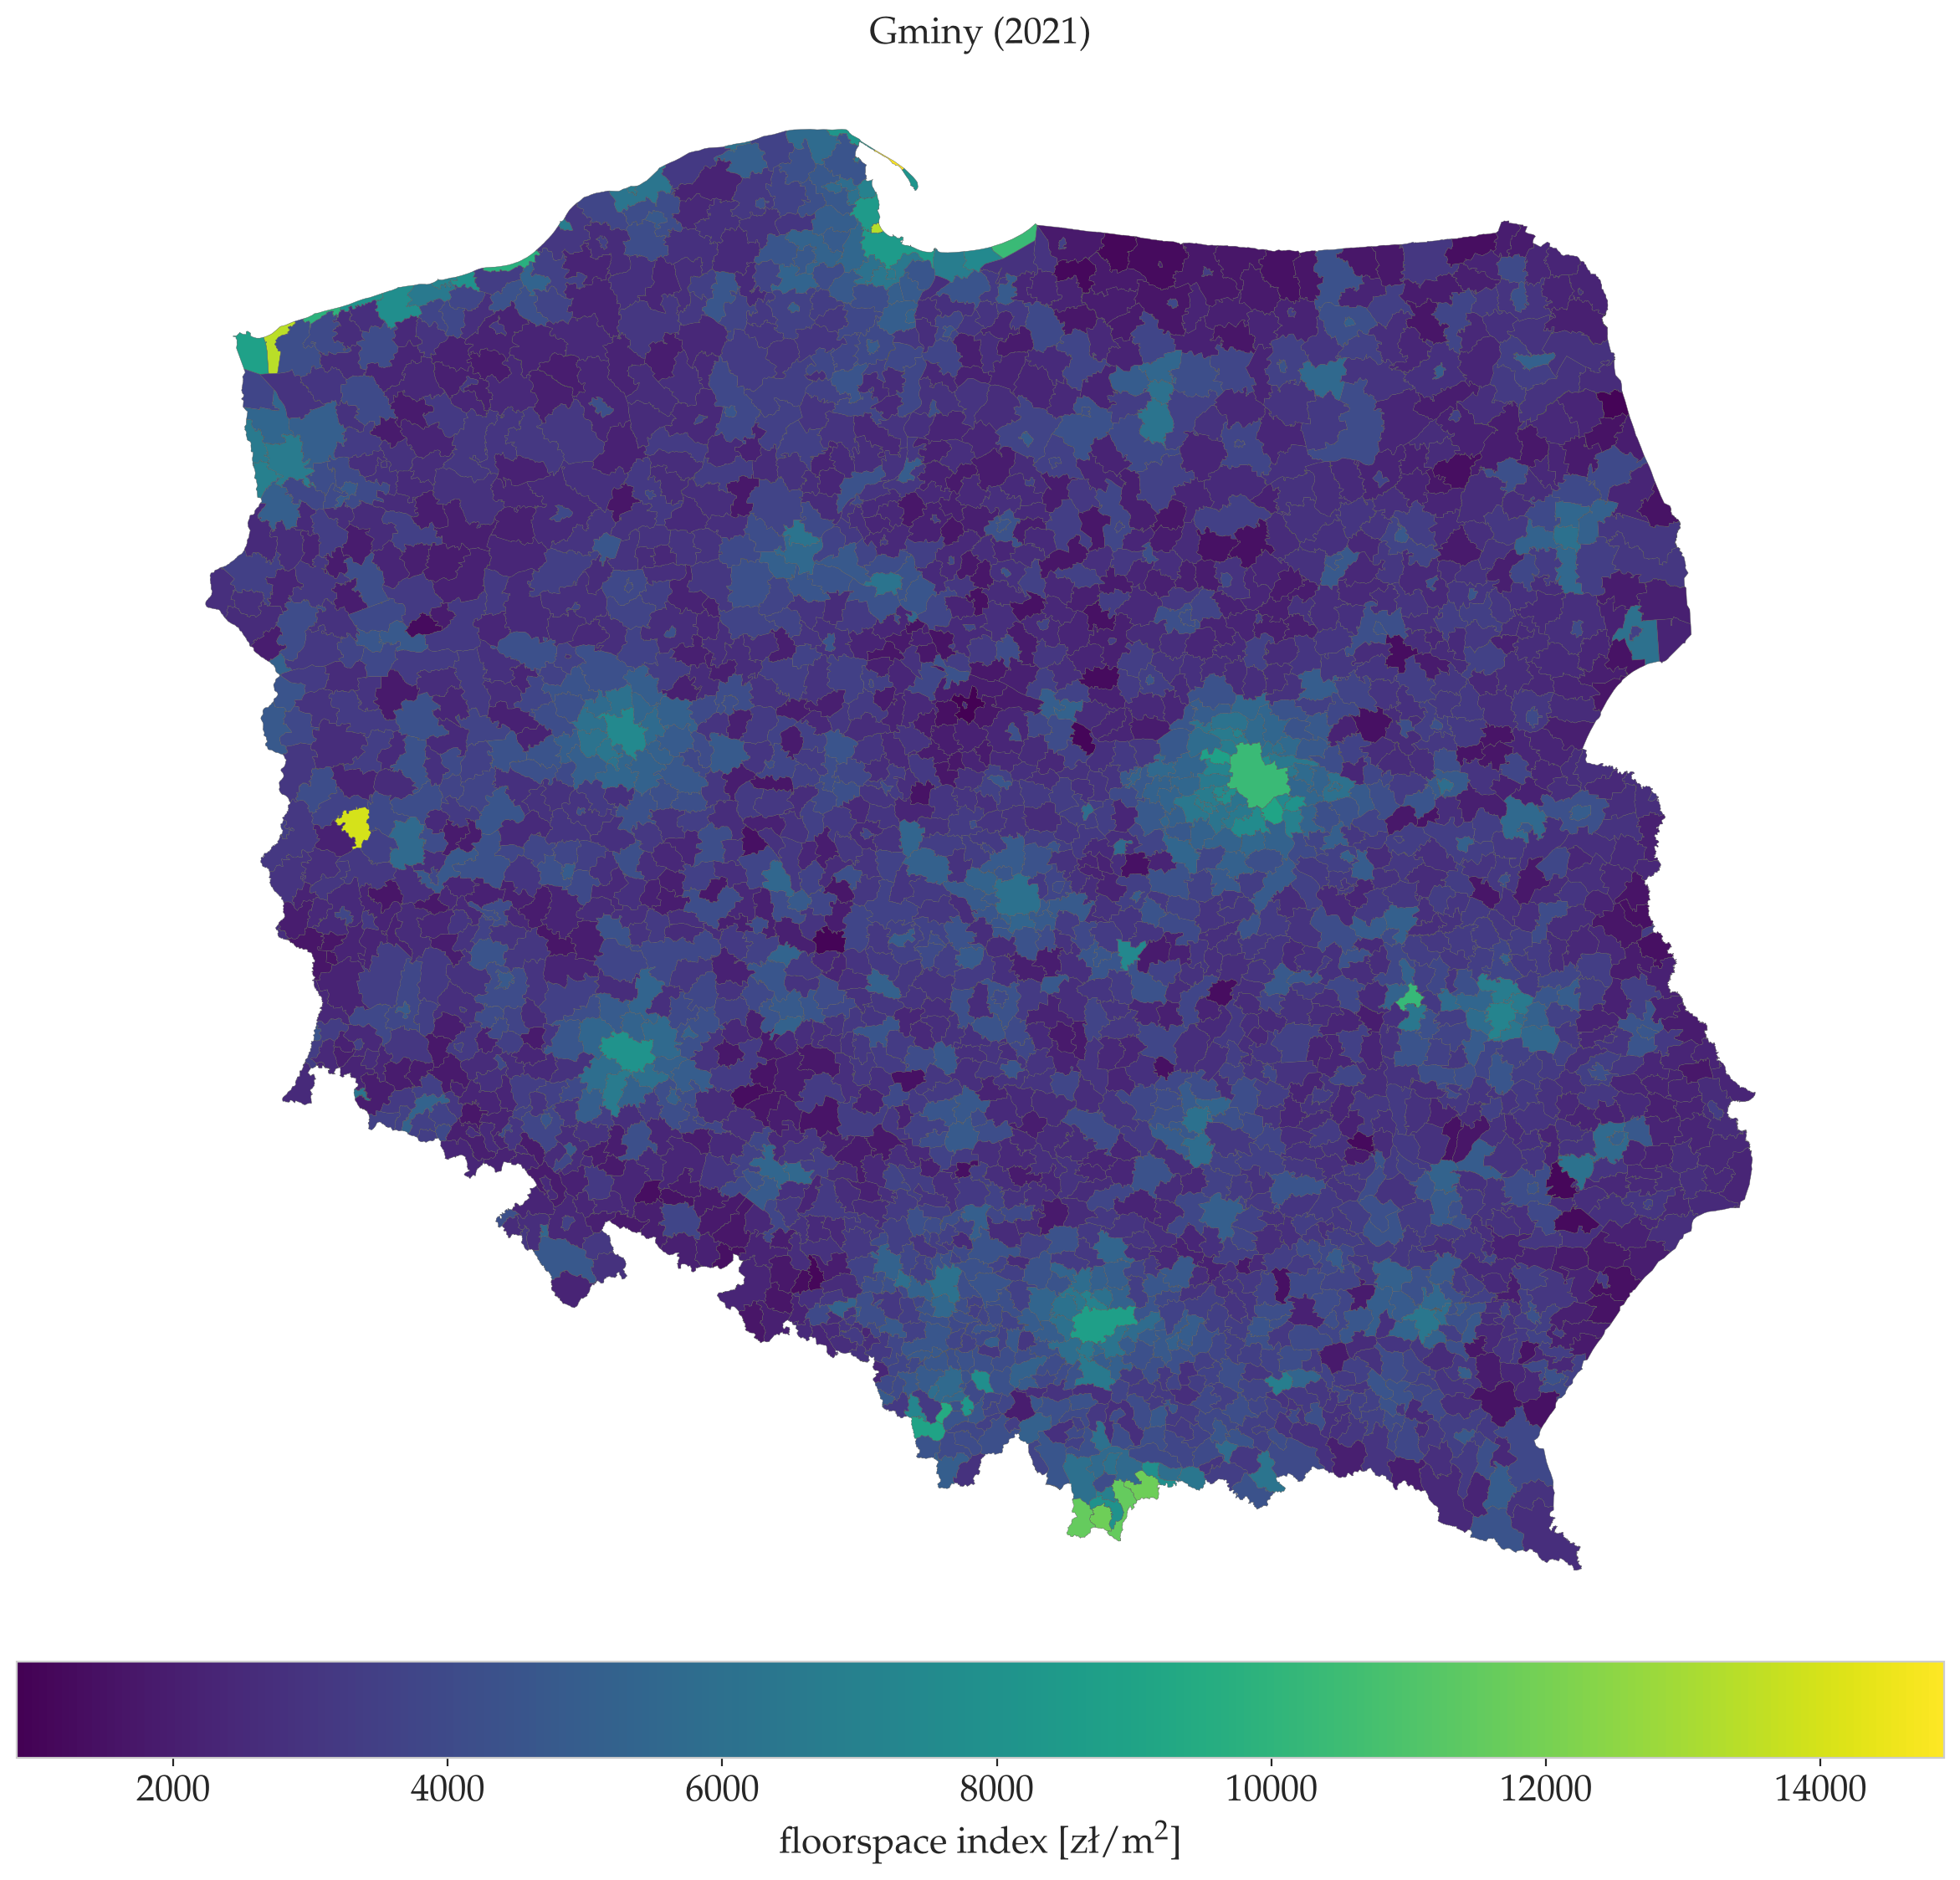

In [4]:
fig, ax = plt.subplots(figsize=(12, 12))

# adjust dpi to 200
fig.set_dpi(200)

# Plot the communes from fpi with column "index_zl_m2" on a viridis scale
fpi.plot(
    ax=ax,
    column="index_zl_m2",
    cmap="viridis",
    linewidth=0.15,
    edgecolor="0.35",
)

# plot the colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=fpi["index_zl_m2"].min(), vmax=fpi["index_zl_m2"].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.01)
cbar.set_label(r"floorspace index [zł/m$^2$]")

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(r"Gminy (2021)")
fig.tight_layout()
plt.show()